**지시사항:**
##1. Gapminder 데이터셋을 불러오고, 2007년도 데이터만 필터링하세요.
##2. 2007년 데이터를 활용하여 아래 그래프를 하나의 Figure 안에 2개의 subplot으로 구성하세요.

(1) 서브플롯 1: 산점도
	x축: gdpPercap
	y축: lifeExp
	각 점은 country
	점 크기: pop(인구), 적절히 스케일 조정
	점 색상: continent 별로 다르게 표시
	범례(legend) 포함
	그래프 제목: "Life Expectancy vs GDP per Capita (2007)"

(2) 서브플롯 2: 대륙별 평균 수명 막대 그래프
	x축: continent
	y축: lifeExp 평균값
	막대 색상은 임의로 지정
	각 막대 위에 평균 수명 값을 텍스트로 표시
	그래프 제목: "Average Life Expectancy by Continent (2007)"

[Figure 전체 조건]
	figsize는 (14, 6) 이상
	plt.tight_layout()으로 레이아웃 조정
	각 subplot에 축 라벨 표시

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30784\2728622665.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


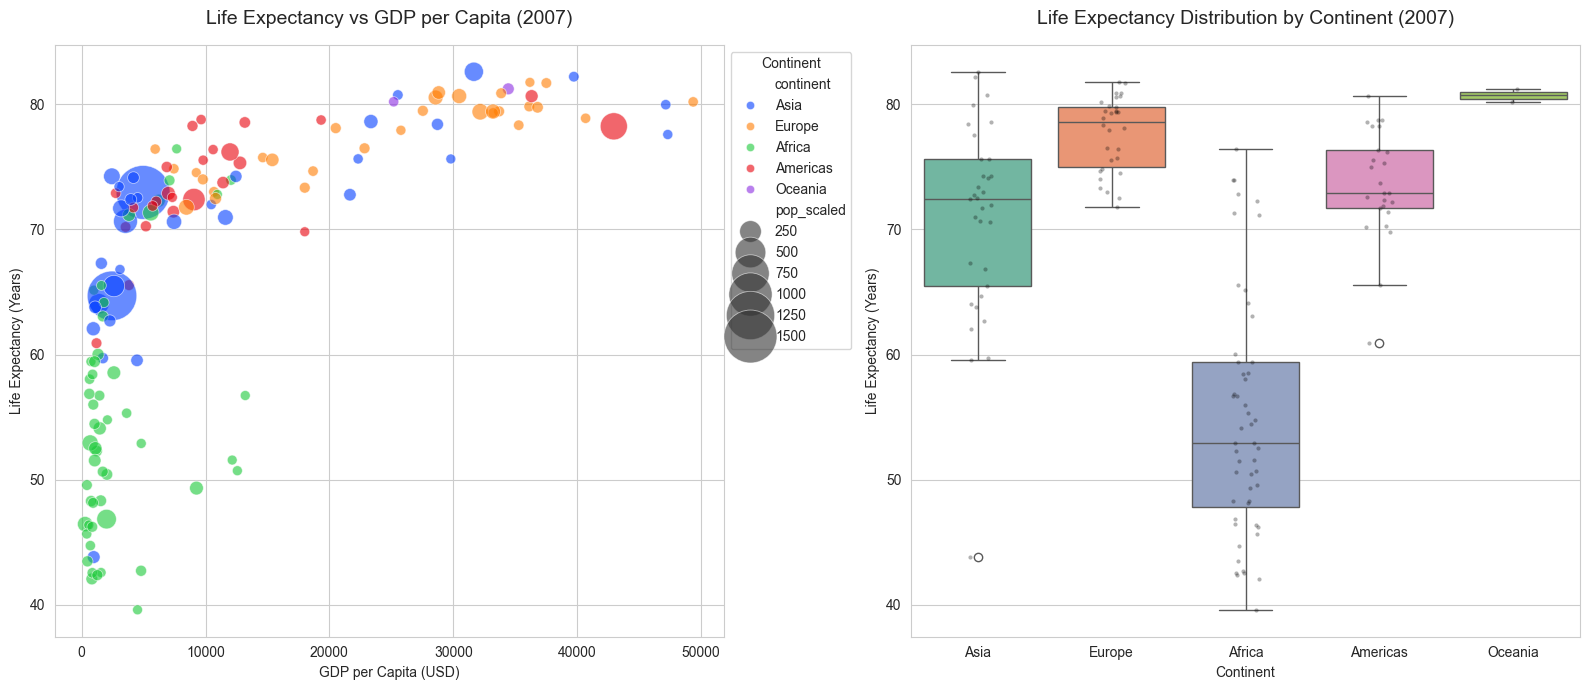

In [ ]:
# (1) 서브플롯 1: 산점도
# 	x축: gdpPercap
# 	y축: lifeExp
# 	각 점은 country
# 	점 크기: pop(인구), 적절히 스케일 조정
# 	점 색상: continent 별로 다르게 표시
# 	범례(legend) 포함
# 	그래프 제목: "Life Expectancy vs GDP per Capita (2007)"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px # Gapminder 데이터셋 로드용

# 1. 데이터 로드 및 2007년도 데이터 필터링
df = px.data.gapminder()
df_2007 = df[df['year'] == 2007].copy()

# 2. Figure 전체 조건 설정 (1행 2열, figsize 14x6 이상)
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

# ---------------------------------------------------------
# (1) 서브플롯 1: 산점도 (Scatter Plot)
# ---------------------------------------------------------
plt.subplot(1, 2, 1)

# 인구(pop)에 따른 점 크기 조정을 위한 정규화 (Min-Max Scaling)
# 점이 너무 작거나 커지지 않도록 50 ~ 1500 사이로 스케일링
pop_min = df_2007['pop'].min()
pop_max = df_2007['pop'].max()
df_2007['pop_scaled'] = (df_2007['pop'] - pop_min) / (pop_max - pop_min) * 1500 + 50

scatter = sns.scatterplot(
    data=df_2007,
    x='gdpPercap',
    y='lifeExp',
    hue='continent',      # 대륙별 색상
    size='pop_scaled',    # 조정된 인구수별 크기
    sizes=(50, 1500),     # 실제 표시될 점의 최소/최대 범위
    alpha=0.6,            # 겹치는 부분을 보기 위한 투명도
    palette='bright',
    edgecolor='w'
)

plt.title("Life Expectancy vs GDP per Capita (2007)", fontsize=14, pad=15)
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Expectancy (Years)")
plt.legend(title="Continent", bbox_to_anchor=(1, 1), loc='upper left')


plt.subplot(1, 2, 2)

sns.boxplot(
    data=df_2007,
    x='continent',
    y='lifeExp',
    palette='Set2'
)

# 박스플롯 위에 실제 데이터 포인트를 덧씌워 분포를 더 명확히 확인 (선택사항)
sns.stripplot(
    data=df_2007,
    x='continent',
    y='lifeExp',
    color='black',
    size=3,
    alpha=0.3
)

plt.title("Life Expectancy Distribution by Continent (2007)", fontsize=14, pad=15)
plt.xlabel("Continent")
plt.ylabel("Life Expectancy (Years)")

# 3. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30784\161245523.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


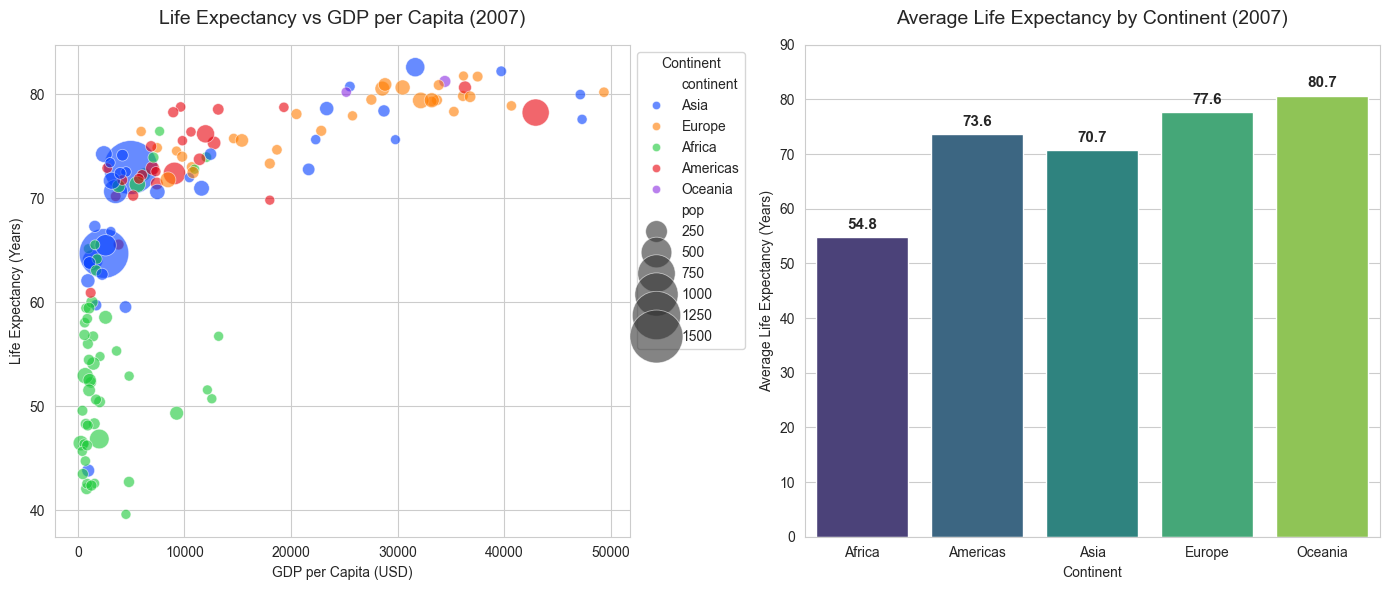

In [ ]:
# (2) 서브플롯 2: 대륙별 평균 수명 막대 그래프
# 	x축: continent
# 	y축: lifeExp 평균값
# 	막대 색상은 임의로 지정
# 	각 막대 위에 평균 수명 값을 텍스트로 표시
# 	그래프 제목: "Average Life Expectancy by Continent (2007)"


df = px.data.gapminder()
df_2007 = df[df['year'] == 2007].copy()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style("whitegrid")

# (1) 서브플롯

size_scale = (df_2007['pop'] - df_2007['pop'].min()) / (df_2007['pop'].max() - df_2007['pop'].min()) * 1500 + 50

sns.scatterplot(
    data=df_2007,
    x='gdpPercap',
    y='lifeExp',
    hue='continent',
    size=size_scale,
    sizes=(50, 1500),
    alpha=0.6,
    palette='bright',
    ax=axes[0]
)

axes[0].set_title("Life Expectancy vs GDP per Capita (2007)", fontsize=14, pad=15)
axes[0].set_xlabel("GDP per Capita (USD)")
axes[0].set_ylabel("Life Expectancy (Years)")
axes[0].legend(title="Continent", bbox_to_anchor=(1, 1), loc='upper left')



# (2) 서브플롯

cont_avg = df_2007.groupby('continent')['lifeExp'].mean().reset_index()

barplot = sns.barplot(
    data=cont_avg,
    x='continent',
    y='lifeExp',
    palette='viridis',
    ax=axes[1]
)


for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.1f'),      
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 9),                      
        textcoords='offset points',
        fontsize=11, fontweight='bold'
    )

axes[1].set_title("Average Life Expectancy by Continent (2007)", fontsize=14, pad=15)
axes[1].set_xlabel("Continent")
axes[1].set_ylabel("Average Life Expectancy (Years)")
axes[1].set_ylim(0, 90)  



plt.tight_layout()
plt.show()